# Proyecto Final Machine Learning
## Fase 2: Modelado y Benchmarking

**Dataset:** UCI HAR — Human Activity Recognition Using Smartphones  
**Equipo:** Grupo 4  
**Integrantes:** Jorge Rojas · Juan Madariaga  
**Fecha:** 22-06-2026
---

> **Objetivo:** Entrenar múltiples modelos de clasificación, evaluarlos con métricas adecuadas y construir una tabla de benchmarking que permita comparar su desempeño de forma rigurosa.

## Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos desde Fase 1

Reutilizamos los datos preparados en la Fase 1. Ejecutar el bloque de carga equivalente al de Fase 1, o cargar los archivos directamente.

In [2]:
# Carga de datos (mismo código que Fase 1)
import os, urllib.request, zipfile

DATA_PATH = 'UCI HAR Dataset'

if not os.path.exists(DATA_PATH):
    URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
    urllib.request.urlretrieve(URL, 'har_dataset.zip')
    with zipfile.ZipFile('har_dataset.zip', 'r') as z:
        z.extractall('.')
    os.remove('har_dataset.zip')

features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

counts = {}
unique_feature_names = []
for n in feature_names:
    if n in counts:
        counts[n] += 1
        unique_feature_names.append(f"{n}_{counts[n]}")
    else:
        counts[n] = 0
        unique_feature_names.append(n)

feature_names = unique_feature_names
X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=feature_names)

# TODO: Cargar y_train (sin header)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['label'])

# TODO: Cargar X_test y asignar feature_names como columnas
X_test = pd.read_csv(f'{DATA_PATH}/test/X_test.txt', sep=r'\s+', header=None, names=feature_names)

# TODO: Cargar y_test (sin header)
y_test = pd.read_csv(f'{DATA_PATH}/test/y_test.txt', sep=r'\s+', header=None, names=['label'])

ACTIVITY_LABELS = {1:'WALKING',2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',4:'SITTING',5:'STANDING',6:'LAYING'}
y_train_labels = y_train['label'].map(ACTIVITY_LABELS)
y_test_labels  = y_test['label'].map(ACTIVITY_LABELS)

print('Datos cargados:')
print(f'  X_train: {X_train.shape} | X_test: {X_test.shape}')

Datos cargados:
  X_train: (7352, 561) | X_test: (2947, 561)


---
## 2. Métricas de Evaluación

Dado que el problema tiene 6 clases, la accuracy sola no es suficiente. Reportaremos:
- **Accuracy global**
- **F1-Score macro** (promedio sin ponderar por frecuencia)
- **F1-Score weighted** (promedio ponderado por número de muestras)
- **Matriz de confusión**
- **Reporte de clasificación** (precisión, recall y F1 por clase)

> ⚠️ Siempre reportar métricas sobre el **conjunto de prueba** (X_test, y_test). Nunca tomar decisiones finales sobre el set de entrenamiento.

In [3]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo, mide tiempo y calcula métricas sobre test."""
    t0 = time.time()
    modelo.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    y_pred = modelo.predict(X_te)

    acc      = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average='macro')
    f1_wgt   = f1_score(y_te, y_pred, average='weighted')

    print(f'\n=== {nombre} ===')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  F1-Macro:     {f1_macro:.4f}')
    print(f'  F1-Weighted:  {f1_wgt:.4f}')
    print(f'  Tiempo fit:   {t_fit:.2f}s')
    print(classification_report(y_te, y_pred))

    return {
        'Modelo': nombre,
        'Accuracy_Test': acc,
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_wgt,
        'Tiempo_Entrenamiento': round(t_fit, 3),
        'modelo_obj': modelo,
        'y_pred': y_pred
    }

resultados = []

---
## 3. Modelo Baseline

Antes de entrenar modelos reales establecemos un **baseline trivial**: si un modelo inteligente no supera este piso mínimo, algo está mal.

In [4]:
# TODO 1: Entrenar DummyClassifier con estrategia 'most_frequent'
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
res_dummy = evaluar_modelo('DummyClassifier (most_frequent)', dummy, X_train, y_train, X_test, y_test)
resultados.append(res_dummy)


=== DummyClassifier (most_frequent) ===
  Accuracy:     0.1822
  F1-Macro:     0.0514
  F1-Weighted:  0.0562
  Tiempo fit:   0.01s
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       496
           2       0.00      0.00      0.00       471
           3       0.00      0.00      0.00       420
           4       0.00      0.00      0.00       491
           5       0.00      0.00      0.00       532
           6       0.18      1.00      0.31       537

    accuracy                           0.18      2947
   macro avg       0.03      0.17      0.05      2947
weighted avg       0.03      0.18      0.06      2947



In [5]:
# TODO 2: Calcular manualmente la accuracy del clasificador trivial
# (predice siempre la clase más frecuente)
clase_frecuente = y_train_labels.value_counts().idxmax()
porcentaje = y_train_labels.value_counts(normalize=True).max()
print(f'Clase más frecuente: {clase_frecuente} ({porcentaje:.2%} del train)')
print(f'Accuracy baseline esperada en test: ~{(y_test_labels == clase_frecuente).mean():.4f}')

Clase más frecuente: LAYING (19.14% del train)
Accuracy baseline esperada en test: ~0.1822


**Análisis:** *[¿Qué accuracy base esperarían superar? ¿Por qué es importante este paso antes de entrenar modelos más complejos?]*

---
## 4. Modelos Clásicos

Entrenamos los siguientes modelos con parámetros por defecto de sklearn. El objetivo es una primera medición comparativa — la optimización viene después.

| # | Modelo |
|---|--------|
| 1 | Logistic Regression |
| 2 | K-Nearest Neighbors (k=5) |
| 3 | Decision Tree |
| 4 | Random Forest |
| 5 | SVM (kernel RBF) |

### Modelo 1: Logistic Regression

In [6]:
# TODO 3: Entrenar Logistic Regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
res_lr = evaluar_modelo('Logistic Regression', lr, X_train, y_train, X_test, y_test)
resultados.append(res_lr)


=== Logistic Regression ===
  Accuracy:     0.9613
  F1-Macro:     0.9612
  F1-Weighted:  0.9612
  Tiempo fit:   34.94s
              precision    recall  f1-score   support

           1       0.95      0.99      0.97       496
           2       0.97      0.94      0.96       471
           3       0.99      0.97      0.98       420
           4       0.98      0.88      0.92       491
           5       0.90      0.98      0.94       532
           6       1.00      1.00      1.00       537

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947



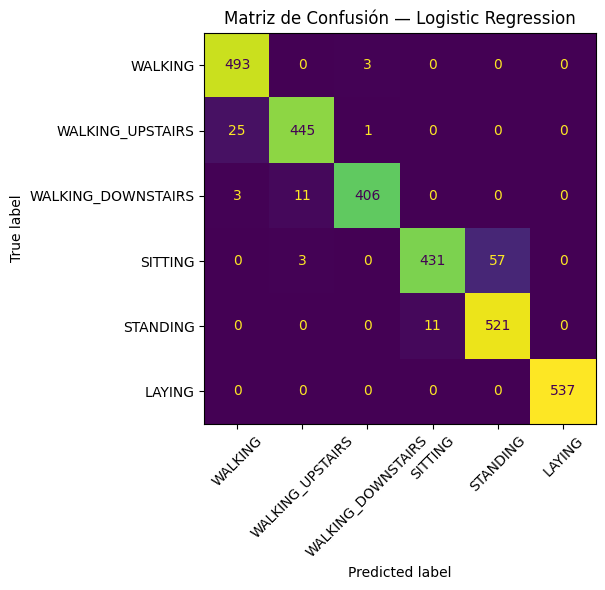

In [15]:
# Matriz de confusión — Logistic Regression
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test['label'], res_lr['y_pred'],
                                      labels=list(ACTIVITY_LABELS.keys())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Logistic Regression')
plt.tight_layout()
plt.show()

### Modelo 2: K-Nearest Neighbors (k=5)

In [8]:
# TODO 4: Entrenar KNN
knn = KNeighborsClassifier(n_neighbors=5)
res_knn = evaluar_modelo('KNN (k=5)', knn, X_train, y_train, X_test, y_test)
resultados.append(res_knn)


=== KNN (k=5) ===
  Accuracy:     0.9016
  F1-Macro:     0.8985
  F1-Weighted:  0.9007
  Tiempo fit:   0.06s
              precision    recall  f1-score   support

           1       0.85      0.98      0.91       496
           2       0.89      0.90      0.90       471
           3       0.95      0.79      0.86       420
           4       0.91      0.79      0.85       491
           5       0.83      0.93      0.88       532
           6       1.00      0.99      1.00       537

    accuracy                           0.90      2947
   macro avg       0.91      0.90      0.90      2947
weighted avg       0.91      0.90      0.90      2947



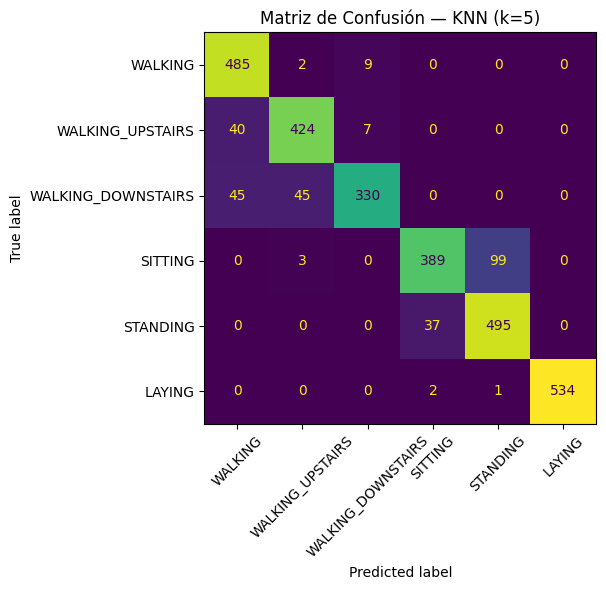

In [16]:
# Matriz de confusión — KNN
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test['label'], res_knn['y_pred'],
                                      labels=list(ACTIVITY_LABELS.keys())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — KNN (k=5)')
plt.tight_layout()
plt.show()

### Modelo 3: Decision Tree

In [9]:
# TODO 5: Entrenar Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
res_dt = evaluar_modelo('Decision Tree', dt, X_train, y_train, X_test, y_test)
resultados.append(res_dt)


=== Decision Tree ===
  Accuracy:     0.8622
  F1-Macro:     0.8595
  F1-Weighted:  0.8617
  Tiempo fit:   6.11s
              precision    recall  f1-score   support

           1       0.83      0.92      0.87       496
           2       0.83      0.78      0.80       471
           3       0.89      0.83      0.86       420
           4       0.83      0.76      0.80       491
           5       0.80      0.86      0.83       532
           6       1.00      1.00      1.00       537

    accuracy                           0.86      2947
   macro avg       0.86      0.86      0.86      2947
weighted avg       0.86      0.86      0.86      2947



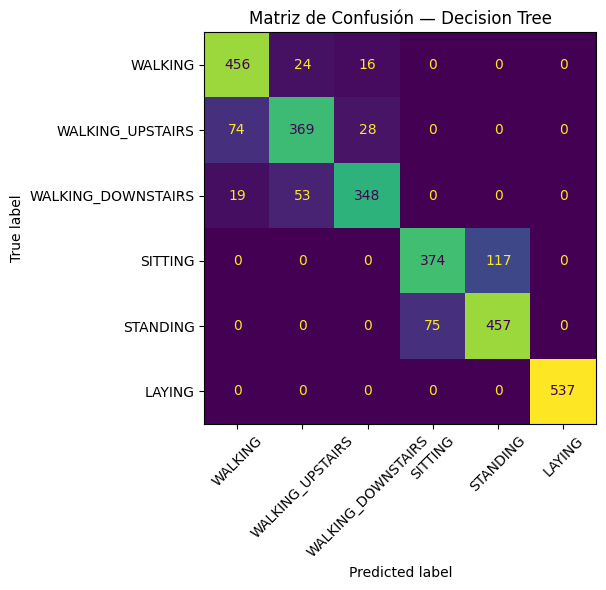

In [17]:
# Matriz de confusión — Decision Tree
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test['label'], res_dt['y_pred'],
                                      labels=list(ACTIVITY_LABELS.keys())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Decision Tree')
plt.tight_layout()
plt.show()

### Modelo 4: Random Forest

In [10]:
# TODO 6: Entrenar Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE)
res_rf = evaluar_modelo('Random Forest', rf, X_train, y_train, X_test, y_test)
resultados.append(res_rf)


=== Random Forest ===
  Accuracy:     0.9257
  F1-Macro:     0.9241
  F1-Weighted:  0.9255
  Tiempo fit:   11.61s
              precision    recall  f1-score   support

           1       0.89      0.97      0.93       496
           2       0.90      0.89      0.89       471
           3       0.97      0.87      0.91       420
           4       0.91      0.89      0.90       491
           5       0.90      0.92      0.91       532
           6       1.00      1.00      1.00       537

    accuracy                           0.93      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.93      0.93      2947



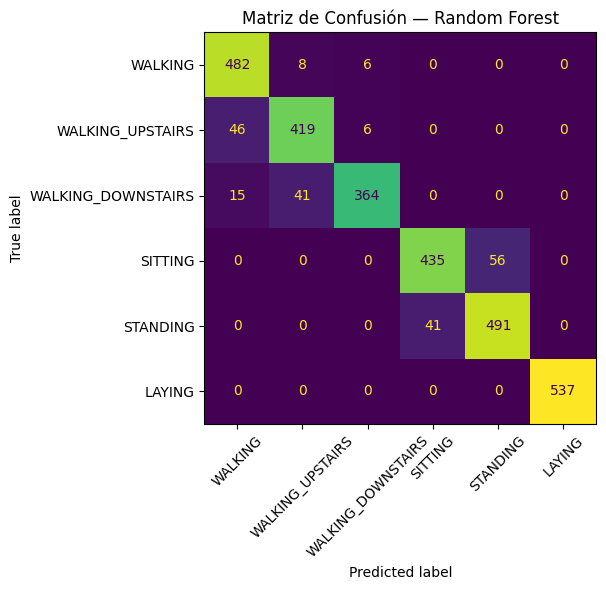

In [18]:
# Matriz de confusión — Random Forest
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test['label'], res_rf['y_pred'],
                                      labels=list(ACTIVITY_LABELS.keys())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — Random Forest')
plt.tight_layout()
plt.show()

### Modelo 5: Support Vector Machine (kernel RBF)

In [11]:
# TODO 7: Entrenar SVM con kernel RBF
# Nota: SVM puede tardar varios minutos en este dataset
svm = SVC(kernel='rbf', random_state=RANDOM_STATE)
res_svm = evaluar_modelo('SVM (RBF)', svm, X_train, y_train, X_test, y_test)
resultados.append(res_svm)


=== SVM (RBF) ===
  Accuracy:     0.9505
  F1-Macro:     0.9499
  F1-Weighted:  0.9504
  Tiempo fit:   1.77s
              precision    recall  f1-score   support

           1       0.94      0.98      0.96       496
           2       0.93      0.96      0.94       471
           3       0.99      0.91      0.95       420
           4       0.94      0.89      0.91       491
           5       0.91      0.95      0.93       532
           6       1.00      1.00      1.00       537

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



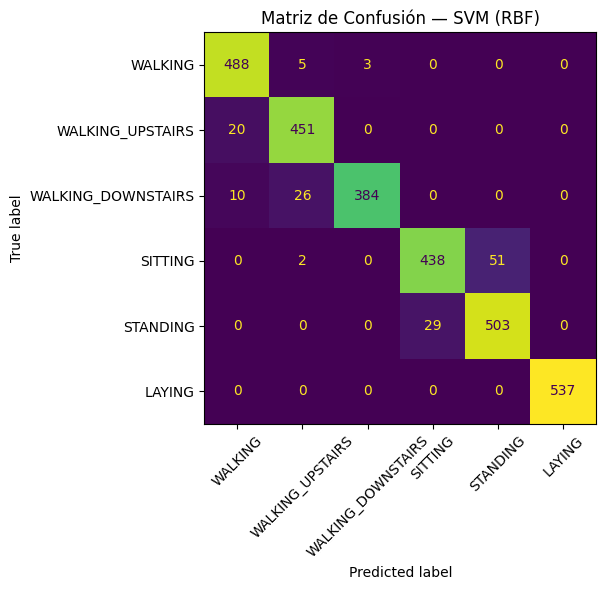

In [19]:
# Matriz de confusión — SVM
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test['label'], res_svm['y_pred'],
                                      labels=list(ACTIVITY_LABELS.keys())),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Matriz de Confusión — SVM (RBF)')
plt.tight_layout()
plt.show()

---
## 5. Tabla de Benchmarking

Comparamos todos los modelos en una tabla única. Esta es la pieza central de la Fase 2.

In [12]:
# TODO 8: Construir DataFrame de benchmarking
# Excluimos la columna 'modelo_obj' y 'y_pred' que son objetos Python
df_bench = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('modelo_obj', 'y_pred')}
    for r in resultados
])

# TODO 9: Ordenar por F1_Macro descendente
df_bench = df_bench.sort_values('F1_Macro', ascending=False).reset_index(drop=True)

print(df_bench.to_string(index=False))

                         Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
            Logistic Regression       0.961317  0.961243     0.961167                34.944
                      SVM (RBF)       0.950458  0.949907     0.950376                 1.772
                  Random Forest       0.925687  0.924103     0.925544                11.608
                      KNN (k=5)       0.901595  0.898521     0.900698                 0.060
                  Decision Tree       0.862233  0.859469     0.861652                 6.107
DummyClassifier (most_frequent)       0.182219  0.051378     0.056172                 0.013


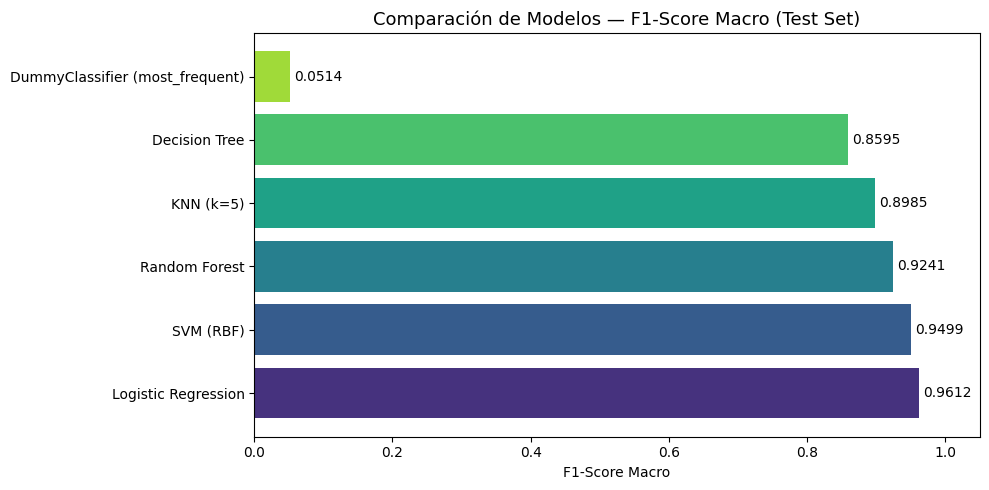

In [20]:
# TODO 10: Graficar barplot comparativo de F1-Macro por modelo
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('viridis', n_colors=len(df_bench))

bars = ax.barh(df_bench['Modelo'], df_bench['F1_Macro'], color=palette)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Comparación de Modelos — F1-Score Macro (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis:** *[Identifica el mejor modelo y justifica la elección considerando tanto la métrica F1-Macro como el tiempo de entrenamiento. ¿Existe un trade-off entre rendimiento y costo computacional?]*

---
## 6. Validación Cruzada del Mejor Modelo

La evaluación sobre un único split puede ser ruidosa. Usamos cross-validation para obtener una estimación más robusta.

In [ ]:
# TODO 11: Aplicar 5-fold CV sobre el mejor modelo
# Reemplazar 'mejor_modelo' por el objeto del modelo ganador
mejor_nombre = df_bench.iloc[0]['Modelo']
mejor_modelo  = next(r['modelo_obj'] for r in resultados if r['Modelo'] == mejor_nombre)

print(f'Aplicando 5-fold CV al modelo: {mejor_nombre}')

# TODO: ejecutar cross_val_score con scoring='f1_macro', cv=5
cv_scores = cross_val_score(
    mejor_modelo, X_train, y_train['label'], cv=5, scoring='f1_macro'
)

print(f'F1-Macro por fold: {cv_scores}')
print(f'Media: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}')

NameError: name 'df_bench' is not defined

**Análisis CV:** *[¿El desempeño en CV es consistente con el desempeño en test? ¿Hay indicios de sobreajuste (alta varianza entre folds)?]*

---
## 7. Análisis de Actividades Difíciles

No todas las actividades son igual de fáciles de clasificar. Identificamos dónde falla el modelo.

In [ ]:
# TODO 12: Extraer F1 por clase del mejor modelo
y_pred_best = next(r['y_pred'] for r in resultados if r['Modelo'] == mejor_nombre)

report_dict = classification_report(
    y_test_labels, y_pred_best, output_dict=True
)

f1_por_clase = {
    cls: report_dict[cls]['f1-score']
    for cls in list(ACTIVITY_LABELS.values())
    if cls in report_dict
}

df_f1_clase = pd.Series(f1_por_clase, name='F1').sort_values()
print(df_f1_clase)

In [ ]:
# TODO 13: Visualizar F1 por clase
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in df_f1_clase.values]
df_f1_clase.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.85, linestyle='--', color='gray', alpha=0.7, label='Umbral 0.85')
ax.set_xlabel('F1-Score')
ax.set_title(f'F1 por Clase — {mejor_nombre}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Análisis de actividades difíciles:**

*[¿Cuáles son las dos actividades con menor F1? Observa la matriz de confusión del mejor modelo y describe con qué otras actividades se confunden. ¿Tiene sentido físico esta confusión? (Pista: considera qué actividades tienen señales de acelerómetro similares.)]*

---
## 8. Resumen de la Fase 2

In [14]:
print('=' * 55)
print('RESUMEN FASE 2')
print('=' * 55)
print(f'Modelos entrenados:    {len(df_bench)}')
print(f'Mejor modelo:          {df_bench.iloc[0]["Modelo"]}')
print(f'F1-Macro (test):       {df_bench.iloc[0]["F1_Macro"]:.4f}')
print(f'Accuracy (test):       {df_bench.iloc[0]["Accuracy_Test"]:.4f}')
print(f'Media CV F1-Macro:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 55)
print('\nTabla completa:')
print(df_bench[['Modelo','Accuracy_Test','F1_Macro','F1_Weighted','Tiempo_Entrenamiento']].to_string(index=False))

RESUMEN FASE 2
Modelos entrenados:    6
Mejor modelo:          Logistic Regression
F1-Macro (test):       0.9612
Accuracy (test):       0.9613


NameError: name 'cv_scores' is not defined